# Plateau Detection — Single Run Example

Train once, then apply three post-hoc detectors to the energy history:

1. **Running-min + patience** — flags when the smoothed energy stays above the best seen so far.
2. **Rolling slope test** — flags when the curve is locally flat *and* above target.
3. **Two-window Welch t-test** — flags when consecutive windows are statistically indistinguishable.

## Imports

In [1]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

from qvarnet.train import train
from qvarnet.models.deep_set import DeepSet
from qvarnet.hamiltonian.continuous import HarmonicOscillatorHamiltonian

## System

In [2]:
N_PARTICLES = 50
DIM         = 1
N_CHAINS    = 5_000
DoF         = N_PARTICLES * DIM
SHAPE       = (N_CHAINS, DoF)

## Model

In [3]:
IS_LOG_MODEL = True

model = DeepSet(
    phi_hidden_architecture=[2],
    F_hidden_architecture=[1],
    hidden_internal_dimension=1,
    n_particles=N_PARTICLES,
)

## Hamiltonian

In [4]:
OMEGA   = 1.0
E_EXACT = 0.5 * OMEGA * N_PARTICLES  # total ground-state energy

## Optimizer

In [5]:
LEARNING_RATE = 0.025

optimizer = optax.adam(learning_rate=LEARNING_RATE)

## Sampler

In [6]:
sampler_params = {
    "step_size":            0.5,
    "chain_length":         11,
    "thermalization_steps": 10,
    "thinning_factor":      1,
    "PBC":                  40.0,
}

## Training

In [7]:
history, _, _ = train(
    n_epochs=10_000,
    shape=SHAPE,
    model=model,
    optimizer=optimizer,
    sampler_params=sampler_params,
    hamiltonian=HarmonicOscillatorHamiltonian(omega=OMEGA),
    rng_seed=42,
    warm_walkers=True,
    is_update_step_size=True,
    is_log_model=IS_LOG_MODEL,
    min_step=1e-5,
    max_step=5.0,
    save_checkpoints=False,
    checkpoint_path="./",
)

100%|██████████| 10000/10000 [01:39<00:00, 100.17it/s, E=29.19, sigma_E=4.60]


## Extract Energy History

In [8]:
# Raw energy per epoch (total, not per particle)
energies = np.array([s.energy for s in history])
epochs   = np.arange(len(energies))

---
# Plateau Detection

All three detectors operate **only on `energies`** — the raw 1-D array from the history.
They return a boolean mask (`True` = plateau at that epoch) and a first-flagged epoch index.

## Shared Helper — Smoothing

In [9]:
def smooth(x, window):
    """Uniform moving average.  Edges are filled with the raw value."""
    if window <= 1:
        return x.copy()
    kernel = np.ones(window) / window
    out = np.convolve(x, kernel, mode="same")
    # fix edge artefacts from zero-padding
    half = window // 2
    for i in range(half):
        out[i]      = x[: i + half + 1].mean()
        out[-i - 1] = x[-(i + half + 1) :].mean()
    return out

## Detector 1 — Running Minimum + Patience

**Logic:** smooth the curve, track the running minimum, flag every epoch where
the smoothed value has stayed `rel_tol` above that minimum for at least
`patience` consecutive epochs.

**Why it catches your pattern:** the curve dips to ~0.5 N, the running min
freezes there, and the patience counter starts ticking once the curve climbs
to ~0.56 N and stays.

In [10]:
def detect_plateau_running_min(
    energies,
    smooth_window=50,
    rel_tol=0.02,
    patience=200,
):
    """
    Parameters
    ----------
    energies     : 1-D array of raw energies.
    smooth_window: width of the moving-average smoother.
    rel_tol      : fractional threshold above running min to count as "worse".
                   E.g. 0.02 → 2 % above best seen so far.
    patience     : consecutive epochs above threshold before flagging.

    Returns
    -------
    mask         : bool array, True where plateau is active.
    first_epoch  : int, first epoch flagged (-1 if never).
    running_min  : smoothed running-minimum array.
    smoothed     : smoothed energy array.
    """
    smoothed    = smooth(energies, smooth_window)
    running_min = np.minimum.accumulate(smoothed)

    above   = smoothed > running_min * (1.0 + rel_tol)  # worse than best by rel_tol
    mask    = np.zeros(len(energies), dtype=bool)
    counter = 0
    flagging = False

    for i, a in enumerate(above):
        if a:
            counter += 1
        else:
            counter  = 0
            flagging = False
        if counter >= patience:
            flagging = True
        if flagging:
            mask[i] = True

    first_epoch = int(np.argmax(mask)) if mask.any() else -1
    return mask, first_epoch, running_min, smoothed


# ── Tune these ───────────────────────────────────────────────────────────────
SMOOTH_W  = 50
REL_TOL   = 0.02   # 2 % above running min
PATIENCE  = 200    # epochs
# ─────────────────────────────────────────────────────────────────────────────

mask1, first1, running_min1, smoothed1 = detect_plateau_running_min(
    energies, smooth_window=SMOOTH_W, rel_tol=REL_TOL, patience=PATIENCE
)

print(f"Detector 1 — Running-min + patience")
print(f"  First plateau epoch : {first1}")
print(f"  Plateau fraction    : {mask1.mean():.1%}")

Detector 1 — Running-min + patience
  First plateau epoch : 5276
  Plateau fraction    : 20.4%


## Detector 2 — Rolling Slope Test

**Logic:** at each epoch, fit a linear trend to the last `window` smoothed values.
Flag when `|slope|` is below `slope_tol` (locally flat) **and** the mean in
that window is above `E_exact + abs_tol` (stuck above target).

In [11]:
def detect_plateau_slope(
    energies,
    e_exact,
    smooth_window=50,
    fit_window=150,
    slope_tol=1e-5,
    abs_tol=0.5,
):
    """
    Parameters
    ----------
    energies     : 1-D raw energy array.
    e_exact      : known exact ground-state energy (total).
    smooth_window: smoother width.
    fit_window   : number of epochs to include in each local linear fit.
    slope_tol    : |slope| threshold (energy units / epoch).
    abs_tol      : how far above e_exact the window mean must be to count.

    Returns
    -------
    mask        : bool array.
    first_epoch : int.
    slopes      : array of local slopes (NaN for the first fit_window epochs).
    smoothed    : smoothed energy array.
    """
    smoothed = smooth(energies, smooth_window)
    n        = len(smoothed)
    slopes   = np.full(n, np.nan)
    mask     = np.zeros(n, dtype=bool)
    x        = np.arange(fit_window, dtype=float)

    for i in range(fit_window, n):
        window_vals = smoothed[i - fit_window : i]
        slope, _    = np.polyfit(x, window_vals, 1)
        slopes[i]   = slope
        flat        = abs(slope) < slope_tol
        above_exact = window_vals.mean() > e_exact + abs_tol
        mask[i]     = flat and above_exact

    first_epoch = int(np.argmax(mask)) if mask.any() else -1
    return mask, first_epoch, slopes, smoothed


# ── Tune these ───────────────────────────────────────────────────────────────
FIT_WINDOW = 150
SLOPE_TOL  = 1e-5   # energy / epoch
ABS_TOL    = 0.5    # absolute energy units above E_exact
# ─────────────────────────────────────────────────────────────────────────────

mask2, first2, slopes2, smoothed2 = detect_plateau_slope(
    energies, E_EXACT,
    smooth_window=SMOOTH_W,
    fit_window=FIT_WINDOW,
    slope_tol=SLOPE_TOL,
    abs_tol=ABS_TOL,
)

print(f"Detector 2 — Rolling slope test")
print(f"  First plateau epoch : {first2}")
print(f"  Plateau fraction    : {mask2.mean():.1%}")

Detector 2 — Rolling slope test
  First plateau epoch : 5297
  Plateau fraction    : 0.8%


## Detector 3 — Two-Window Welch t-test

**Logic:** compare the mean of a recent window (last `w_recent` epochs) against
an older reference window (`w_ref` epochs, shifted back by `gap` epochs).
Flag when the two distributions are statistically indistinguishable
(`p > p_thresh`) **and** the recent mean is above `E_exact + abs_tol`.

In [12]:
def detect_plateau_ttest(
    energies,
    e_exact,
    smooth_window=50,
    w_recent=100,
    w_ref=100,
    gap=100,
    p_thresh=0.05,
    abs_tol=0.5,
):
    """
    Parameters
    ----------
    energies     : 1-D raw energy array.
    e_exact      : known exact ground-state energy (total).
    smooth_window: smoother width.
    w_recent     : size of the recent window.
    w_ref        : size of the reference (older) window.
    gap          : epoch gap between the end of the ref window and the start of recent.
    p_thresh     : Welch t-test p-value above which we call the windows "the same".
    abs_tol      : how far above e_exact the recent mean must be to count.

    Returns
    -------
    mask        : bool array.
    first_epoch : int.
    p_values    : array of p-values (NaN before enough history is available).
    smoothed    : smoothed energy array.
    """
    smoothed = smooth(energies, smooth_window)
    n        = len(smoothed)
    p_values = np.full(n, np.nan)
    mask     = np.zeros(n, dtype=bool)
    min_i    = w_recent + gap + w_ref

    for i in range(min_i, n):
        recent = smoothed[i - w_recent : i]
        ref    = smoothed[i - w_recent - gap - w_ref : i - w_recent - gap]
        _, p   = stats.ttest_ind(recent, ref, equal_var=False)
        p_values[i]  = p
        stagnant     = p > p_thresh
        above_exact  = recent.mean() > e_exact + abs_tol
        mask[i]      = stagnant and above_exact

    first_epoch = int(np.argmax(mask)) if mask.any() else -1
    return mask, first_epoch, p_values, smoothed


# ── Tune these ───────────────────────────────────────────────────────────────
W_RECENT  = 100
W_REF     = 100
GAP       = 100
P_THRESH  = 0.05
ABS_TOL   = 0.5
# ─────────────────────────────────────────────────────────────────────────────

mask3, first3, p_values3, smoothed3 = detect_plateau_ttest(
    energies, E_EXACT,
    smooth_window=SMOOTH_W,
    w_recent=W_RECENT,
    w_ref=W_REF,
    gap=GAP,
    p_thresh=P_THRESH,
    abs_tol=ABS_TOL,
)

print(f"Detector 3 — Two-window Welch t-test")
print(f"  First plateau epoch : {first3}")
print(f"  Plateau fraction    : {mask3.mean():.1%}")

Detector 3 — Two-window Welch t-test
  First plateau epoch : 5412
  Plateau fraction    : 4.0%


## Summary Table

In [13]:
print(f"{'Detector':<35} {'First flagged':>15} {'Plateau fraction':>18}")
print("-" * 70)
rows = [
    ("1 · Running-min + patience",  first1, mask1),
    ("2 · Rolling slope test",       first2, mask2),
    ("3 · Two-window Welch t-test",  first3, mask3),
]
for name, first, mask in rows:
    f = f"epoch {first}" if first >= 0 else "never"
    print(f"{name:<35} {f:>15} {mask.mean():>17.1%}")

Detector                              First flagged   Plateau fraction
----------------------------------------------------------------------
1 · Running-min + patience               epoch 5276             20.4%
2 · Rolling slope test                   epoch 5297              0.8%
3 · Two-window Welch t-test              epoch 5412              4.0%


## Visualisation — Energy + Plateau Regions

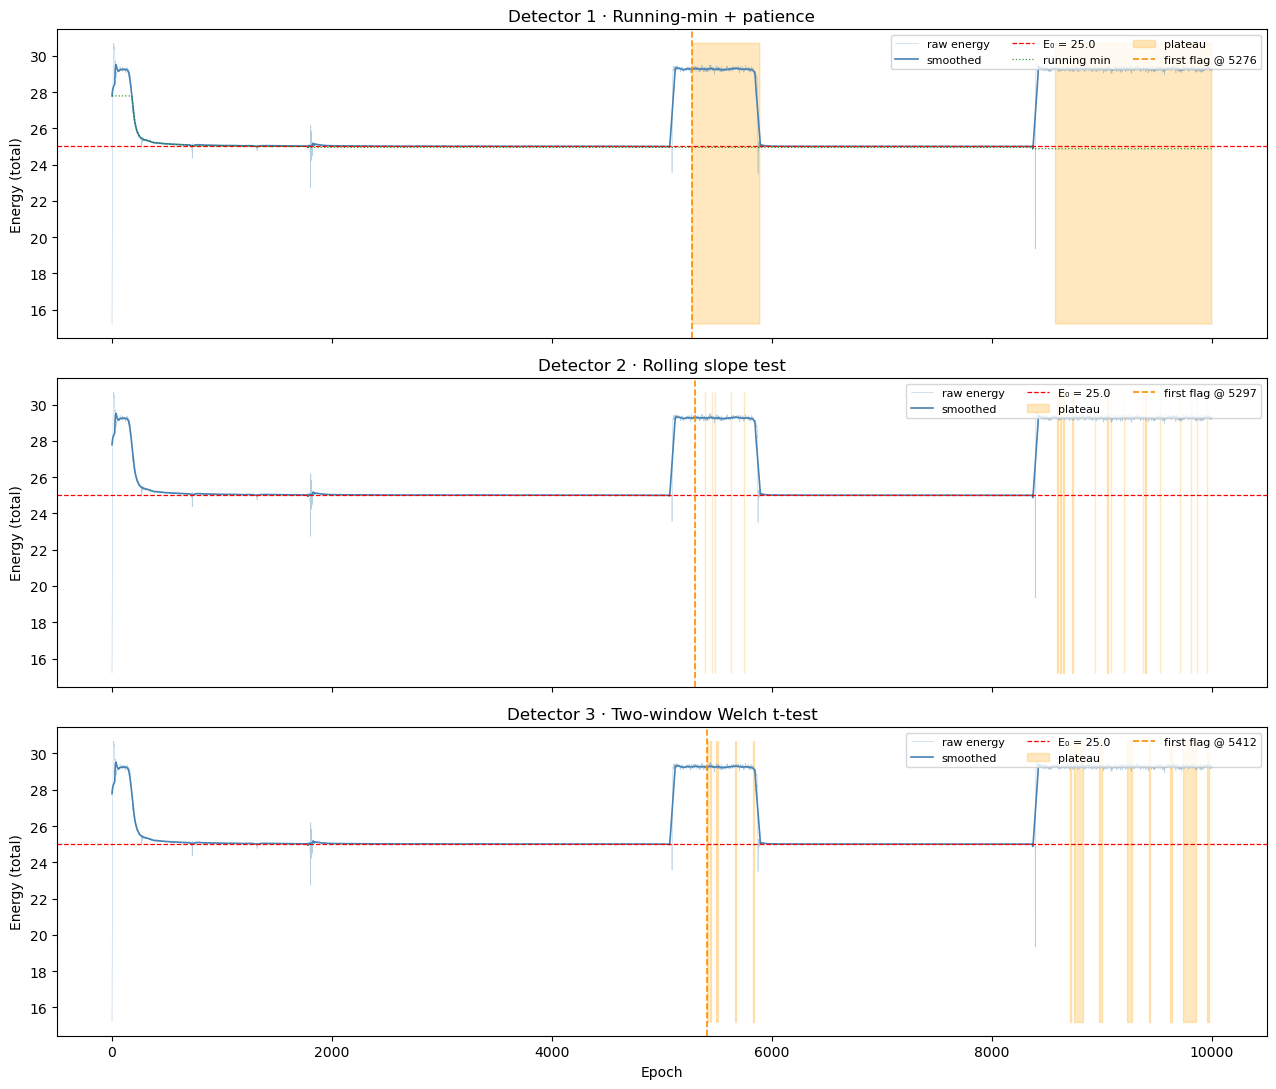

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

detector_info = [
    (axes[0], mask1, smoothed1, first1, "Detector 1 · Running-min + patience",
     running_min1, "running min"),
    (axes[1], mask2, smoothed2, first2, "Detector 2 · Rolling slope test",
     None, None),
    (axes[2], mask3, smoothed3, first3, "Detector 3 · Two-window Welch t-test",
     None, None),
]

for ax, mask, smoothed, first, title, extra_line, extra_label in detector_info:
    # raw energy (light)
    ax.plot(epochs, energies, lw=0.4, color="steelblue", alpha=0.4, label="raw energy")
    # smoothed energy
    ax.plot(epochs, smoothed, lw=1.2, color="steelblue", label="smoothed")
    # exact ground state
    ax.axhline(E_EXACT, color="red", ls="--", lw=0.9, label=f"E₀ = {E_EXACT:.1f}")

    # optional extra line (running min)
    if extra_line is not None:
        ax.plot(epochs, extra_line, lw=0.9, color="green",
                ls=":", alpha=0.8, label=extra_label)

    # shade plateau regions
    if mask.any():
        ax.fill_between(epochs, energies.min(), energies.max(),
                        where=mask, color="orange", alpha=0.25, label="plateau")
        ax.axvline(first, color="darkorange", lw=1.2, ls="--",
                   label=f"first flag @ {first}")

    ax.set_ylabel("Energy (total)")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right", ncol=3)

axes[-1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig("plateau_detection.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisation — Detector Diagnostics

Shows the internal signals of each detector so you can understand *why* it fired.

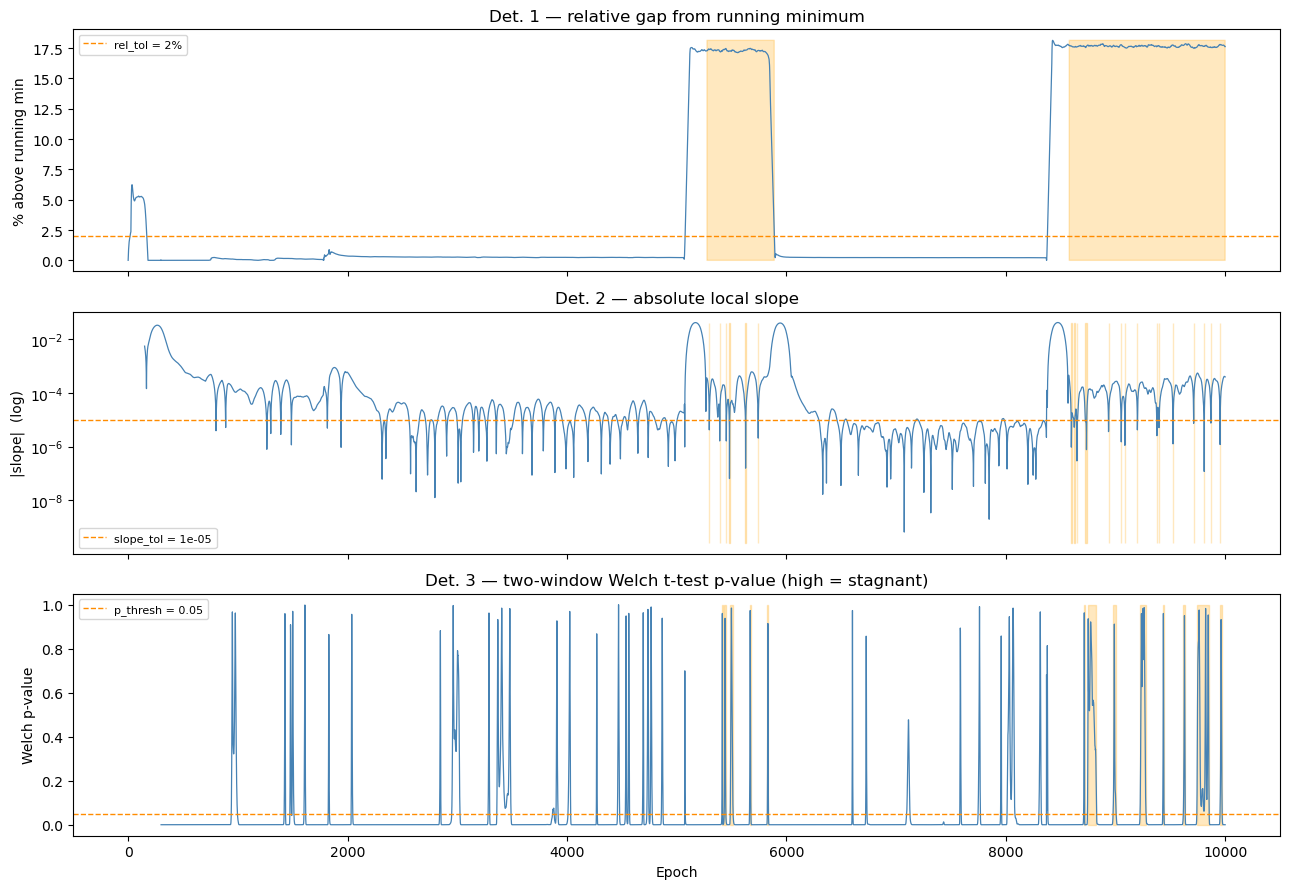

: 

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# ── Detector 1: distance from running min ──────────────────────────────────
ax = axes[0]
gap_from_min = (smoothed1 - running_min1) / np.abs(running_min1).clip(1e-12)
ax.plot(epochs, gap_from_min * 100, lw=0.9, color="steelblue")
ax.axhline(REL_TOL * 100, color="darkorange", ls="--", lw=1,
           label=f"rel_tol = {REL_TOL:.0%}")
if mask1.any():
    ax.fill_between(epochs, 0, gap_from_min.max() * 100,
                    where=mask1, color="orange", alpha=0.25)
ax.set_ylabel("% above running min")
ax.set_title("Det. 1 — relative gap from running minimum")
ax.legend(fontsize=8)

# ── Detector 2: local slope ────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, np.abs(slopes2), lw=0.9, color="steelblue")
ax.axhline(SLOPE_TOL, color="darkorange", ls="--", lw=1,
           label=f"slope_tol = {SLOPE_TOL:.0e}")
ax.set_yscale("log")
if mask2.any():
    ax.fill_between(epochs, ax.get_ylim()[0], np.nanmax(np.abs(slopes2)),
                    where=mask2, color="orange", alpha=0.25)
ax.set_ylabel("|slope|  (log)")
ax.set_title("Det. 2 — absolute local slope")
ax.legend(fontsize=8)

# ── Detector 3: t-test p-value ─────────────────────────────────────────────
ax = axes[2]
ax.plot(epochs, p_values3, lw=0.9, color="steelblue")
ax.axhline(P_THRESH, color="darkorange", ls="--", lw=1,
           label=f"p_thresh = {P_THRESH}")
if mask3.any():
    ax.fill_between(epochs, 0, 1, where=mask3, color="orange", alpha=0.25)
ax.set_ylabel("Welch p-value")
ax.set_title("Det. 3 — two-window Welch t-test p-value (high = stagnant)")
ax.set_xlabel("Epoch")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plateau_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()